[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module2/3_Fashion_MNIST_with_fashion_images.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 17 (M2.3) - Fashion MNIST: same recipe, harder problem

- Swap digits for 10 clothing categories, keep the whole recipe: /255, flatten, dense, softmax -> ~88%.
- Point at the drop from 98% to 88%: shirts vs pullovers genuinely look alike at 28x28. Harder data, same code.
- ~450k parameters - have them predict the count before revealing (the video 2 skill, now at scale).
- Message: the recipe transfers. Change the data, keep the skeleton.
-->

# A first look at a neural network with Fashion MNIST
-----------------------
**Dr. Dave Wanik**

This notebook contains the code samples found in Chapter 2, Section 1 of [Deep Learning with Python](https://www.manning.com/books/deep-learning-with-python?a_aid=keras&a_bid=76564dff). Note that the original text features far more content, in particular further explanations and figures: in this notebook, you will only find source code and related comments.

----

We will now take a look at a first concrete example of a neural network, which makes use of the Python library Keras to learn to classify
hand-written digits. Unless you already have experience with Keras or similar libraries, you will not understand everything about this
first example right away. You probably haven't even installed Keras yet. Don't worry, that is perfectly fine. In the next chapter, we will
review each element in our example and explain them in detail. So don't worry if some steps seem arbitrary or look like magic to you!
We've got to start somewhere.

The problem we are trying to solve here is to classify grayscale images of handwritten digits (28 pixels by 28 pixels), into their 10
categories (0 to 9). The dataset we will use is the MNIST dataset, a classic dataset in the machine learning community, which has been
around for almost as long as the field itself and has been very intensively studied. It's a set of 60,000 training images, plus 10,000 test
images, assembled by the National Institute of Standards and Technology (the NIST in MNIST) in the 1980s. You can think of "solving" MNIST
as the "Hello World" of deep learning -- it's what you do to verify that your algorithms are working as expected. As you become a machine
learning practitioner, you will see MNIST come up over and over again, in scientific papers, blog posts, and so on.

The MNIST dataset comes pre-loaded in Keras, in the form of a set of four Numpy arrays:

In [1]:
from keras.datasets import fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

`train_images` and `train_labels` form the "training set", the data that the model will learn from. The model will then be tested on the
"test set", `test_images` and `test_labels`. Our images are encoded as Numpy arrays, and the labels are simply an array of digits, ranging
from 0 to 9. There is a one-to-one correspondence between the images and the labels.

Let's have a look at the training data:

In [2]:
train_images.shape

(60000, 28, 28)

In [3]:
len(train_labels)

60000

In [4]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

In [5]:
tmp = train_labels
import pandas as pd
tmp = pd.DataFrame(tmp)
tmp[0].value_counts()

0
9    6000
0    6000
3    6000
2    6000
7    6000
5    6000
1    6000
6    6000
4    6000
8    6000
Name: count, dtype: int64

## Look at one image...
Just to get a feel for the data.

In [6]:
# look at one image
import pandas as pd
import numpy as np
import sys

# subset first 'image'
x = train_images[0]
# convert to pandas dataframe for easy viewing...
x = pd.DataFrame(x)
print(x.shape) # 28 rows and 28 columns
# you can confirm
print(train_labels[0])
x # it's the number 9!



(28, 28)
9


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,4,0,0,0,0,1,1,0
4,0,0,0,0,0,0,0,0,0,0,...,54,0,0,0,1,3,4,0,0,3
5,0,0,0,0,0,0,0,0,0,0,...,144,123,23,0,0,0,0,12,10,0
6,0,0,0,0,0,0,0,0,0,0,...,107,156,161,109,64,23,77,130,72,15
7,0,0,0,0,0,0,0,0,0,0,...,216,163,127,121,122,146,141,88,172,66
8,0,0,0,0,0,0,0,0,0,1,...,223,223,215,213,164,127,123,196,229,0
9,0,0,0,0,0,0,0,0,0,0,...,235,227,224,222,224,221,223,245,173,0


Let's have a look at the test data:

In [7]:
test_images.shape

(10000, 28, 28)

In [8]:
len(test_labels)

10000

In [9]:
test_labels[0:10] # just a sample of them

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7], dtype=uint8)

In [10]:
# check out value counts
tmp = test_labels
import pandas as pd
tmp = pd.DataFrame(tmp)
tmp[0].value_counts()

0
9    1000
2    1000
1    1000
6    1000
4    1000
5    1000
7    1000
3    1000
8    1000
0    1000
Name: count, dtype: int64

## So what score do we have to beat?

Same question we ask every single time... what does the laziest possible model get?

Look at those counts: ten clothing categories, exactly **1,000 images each**. Perfectly balanced. So always guessing one category - never even looking at the picture - scores exactly **10%**. That's our floor.

Keep that 10% in your pocket. This problem is harder than the digits, so we won't hit 98% here... but even 88% is a long, long way above what you'd get for free. **Always report your accuracy next to its baseline** - a number by itself doesn't tell anybody whether the model learned anything.

In [11]:
# making a copy for later (logistic regression)
copy_train_labels = train_labels
copy_test_labels = test_labels

Our workflow will be as follow: first we will present our neural network with the training data, `train_images` and `train_labels`. The
network will then learn to associate images and labels. Finally, we will ask the network to produce predictions for `test_images`, and we
will verify if these predictions match the labels from `test_labels`.

Let's build our network -- again, remember that you aren't supposed to understand everything about this example just yet.

In [12]:
from keras import models
from keras import layers
from keras.layers import Dense, Dropout

network = models.Sequential()
network.add(Dense(512, activation='relu', input_shape=(28 * 28,))) # (features, )
network.add(Dropout(0.2))
network.add(Dense(100, activation='relu'))
network.add(Dropout(0.2))
network.add(Dense(10, activation='softmax'))
network.summary()

# note: input shape is the trickiest part IMHO...
# think of it as (number of columns, number of samples)
# number of samples is ALWAYS left blank (you'll set the batch size later on!)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        51,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 454,230 (1.73 MB)

 Trainable params: 454,230 (1.73 MB)

 Non-trainable params: 0 (0.00 B)


The core building block of neural networks is the "layer", a data-processing module which you can conceive as a "filter" for data. Some
data comes in, and comes out in a more useful form. Precisely, layers extract _representations_ out of the data fed into them -- hopefully
representations that are more meaningful for the problem at hand. Most of deep learning really consists of chaining together simple layers
which will implement a form of progressive "data distillation". A deep learning model is like a sieve for data processing, made of a
succession of increasingly refined data filters -- the "layers".

Here our network consists of a sequence of two `Dense` layers, which are densely-connected (also called "fully-connected") neural layers.
The second (and last) layer is a 10-way "softmax" layer, which means it will return an array of 10 probability scores (summing to 1). Each
score will be the probability that the current digit image belongs to one of our 10 digit classes.

To make our network ready for training, we need to pick three more things, as part of "compilation" step:

* A loss function: the is how the network will be able to measure how good a job it is doing on its training data, and thus how it will be
able to steer itself in the right direction.
* An optimizer: this is the mechanism through which the network will update itself based on the data it sees and its loss function.
* Metrics to monitor during training and testing. Here we will only care about accuracy (the fraction of the images that were correctly
classified).

The exact purpose of the loss function and the optimizer will be made clear throughout the next two chapters.

In [13]:
network.compile(optimizer='rmsprop', # you could use rmsprop or Adam - both are good!
                loss='categorical_crossentropy', # many categories - you need to use 'categorical_crossentropy' and NOT 'binary_crossentropy'
                metrics=['accuracy'])


Before training, we will preprocess our data by reshaping it into the shape that the network expects, and scaling it so that all values are in
the `[0, 1]` interval. Previously, our training images for instance were stored in an array of shape `(60000, 28, 28)` of type `uint8` with
values in the `[0, 255]` interval. We transform it into a `float32` array of shape `(60000, 28 * 28)` with values between 0 and 1.

In [14]:
28*28

784

In [15]:
train_images = train_images.reshape((60000, 28 * 28)) # 60K rows, with 784 columns... wow!
train_images = train_images.astype('float32') / 255 # here we are scaling by max pixel value (where white =255, black = 0)

test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype('float32') / 255

In [16]:
# BE CURIOUS!
# see what the model did
x = train_images[0] # instead of a 2D array that is 28*28, it's a single row!
x

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [17]:
# you can see this in the entire dataset too
x = pd.DataFrame(train_images)
print(x.shape)
print(28*28) # see how the shape matches up?
x.head(n=10)

# that first sample is now just the first row

(60000, 784)
784


,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.000000,0.003922,0.000000,0.0,0.000000,0.000000,...,0.466667,0.447059,0.509804,0.298039,0.000000,0.000000,0.000000,0.00000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.086275,...,0.000000,0.000000,0.003922,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.129412,0.376471,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0
5,0.0,0.0,0.0,0.0,0.003922,0.000000,0.000000,0.0,0.000000,0.086275,...,0.000000,0.000000,0.000000,0.000000,0.521569,0.654902,0.286275,0.00000,0.0,0.0
6,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0
7,0.0,0.0,0.0,0.0,0.000000,0.003922,0.003922,0.0,0.000000,0.000000,...,0.000000,0.000000,0.011765,0.000000,0.321569,0.929412,0.905882,0.27451,0.0,0.0
8,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0
9,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0


We also need to categorically encode the labels, a step which we explain in Chapter 3:

In [18]:
from tensorflow.keras.utils import to_categorical

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [19]:
# BE CURIOUS! See what it looks like
x = train_labels[0]
print(x)
# check out the output - the first sample

[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [20]:
# check them ALL out!
x = train_labels
x = pd.DataFrame(x)
x

# so the labels are in an ARRAY with one column for each potential outcome.

,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
59995,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
59996,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59997,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
59998,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We are now ready to train our network, which in Keras is done via a call to the `fit` method of the network:
we "fit" the model to its training data.

In [21]:
# on your own, you are welcome to try including early stopping callbacks
history = network.fit(train_images, train_labels, epochs=30, batch_size=128, validation_split=0.2, shuffle=True)

Epoch 1/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 7:33 1s/step - accuracy: 0.1562 - loss: 2.3664

  9/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4158 - loss: 1.6924 

 17/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4926 - loss: 1.4547

 25/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5534 - loss: 1.2723

 33/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5824 - loss: 1.1817

 41/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6115 - loss: 1.1033

 49/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6263 - loss: 1.0568

 57/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6387 - loss: 1.0193

 64/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6499 - loss: 0.9868

 71/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6582 - loss: 0.9586

 79/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6670 - loss: 0.9301

 86/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6737 - loss: 0.9078

 93/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6806 - loss: 0.8914

100/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6872 - loss: 0.8737

107/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6922 - loss: 0.8577

114/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6983 - loss: 0.8391

121/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7025 - loss: 0.8274

128/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7068 - loss: 0.8158

135/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7098 - loss: 0.8077

142/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7142 - loss: 0.7967

149/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7174 - loss: 0.7873

156/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7198 - loss: 0.7808

163/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7230 - loss: 0.7730

170/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7262 - loss: 0.7661

177/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7290 - loss: 0.7572

185/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7314 - loss: 0.7491

192/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7345 - loss: 0.7402

200/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7374 - loss: 0.7319

208/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7391 - loss: 0.7268

216/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7422 - loss: 0.7176

224/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7448 - loss: 0.7105

232/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7473 - loss: 0.7033

240/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7499 - loss: 0.6956

248/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7518 - loss: 0.6898

256/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7537 - loss: 0.6846

265/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7558 - loss: 0.6788

273/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7568 - loss: 0.6747

281/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7578 - loss: 0.6715

289/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7599 - loss: 0.6664

297/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7614 - loss: 0.6612

305/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7625 - loss: 0.6574

313/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7640 - loss: 0.6534

320/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7647 - loss: 0.6506

328/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7662 - loss: 0.6471

336/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7679 - loss: 0.6424

343/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7691 - loss: 0.6392

351/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7701 - loss: 0.6360

359/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7713 - loss: 0.6328

367/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7727 - loss: 0.6292

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7739 - loss: 0.6261

375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7739 - loss: 0.6261 - val_accuracy: 0.8482 - val_loss: 0.4183


Epoch 2/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.8594 - loss: 0.3904

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8164 - loss: 0.4931  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8224 - loss: 0.4863

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8304 - loss: 0.4741

 37/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8330 - loss: 0.4588

 46/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8315 - loss: 0.4596

 55/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8325 - loss: 0.4620

 64/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8306 - loss: 0.4609

 73/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8305 - loss: 0.4564

 82/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8290 - loss: 0.4587

 91/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8300 - loss: 0.4593

100/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8309 - loss: 0.4585

109/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8303 - loss: 0.4582

117/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8309 - loss: 0.4563

125/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8322 - loss: 0.4539

133/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8341 - loss: 0.4514

142/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8353 - loss: 0.4486

151/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8346 - loss: 0.4494

159/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8349 - loss: 0.4498

168/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8340 - loss: 0.4488

177/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8359 - loss: 0.4470

185/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8366 - loss: 0.4451

194/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8369 - loss: 0.4436

202/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8373 - loss: 0.4420

210/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8368 - loss: 0.4426

218/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8365 - loss: 0.4423

226/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8369 - loss: 0.4405

234/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8373 - loss: 0.4388

242/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8376 - loss: 0.4387

251/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8369 - loss: 0.4404

259/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8372 - loss: 0.4397

268/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8377 - loss: 0.4388

277/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8383 - loss: 0.4379

286/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8384 - loss: 0.4373

294/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8383 - loss: 0.4370

302/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8384 - loss: 0.4366

310/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8385 - loss: 0.4362

317/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8387 - loss: 0.4363

325/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8390 - loss: 0.4355

333/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8396 - loss: 0.4338

341/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8394 - loss: 0.4338

349/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8401 - loss: 0.4334

357/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8404 - loss: 0.4330

365/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8409 - loss: 0.4322

373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8414 - loss: 0.4313

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8414 - loss: 0.4312 - val_accuracy: 0.8633 - val_loss: 0.3797


Epoch 3/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.8906 - loss: 0.3461

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8508 - loss: 0.4042  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8499 - loss: 0.4085

 27/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8527 - loss: 0.4066

 35/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8547 - loss: 0.3977

 43/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8570 - loss: 0.3957

 52/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8573 - loss: 0.3986

 60/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8595 - loss: 0.3916

 69/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8593 - loss: 0.3925

 78/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8600 - loss: 0.3917

 86/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8598 - loss: 0.3911

 94/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8586 - loss: 0.3953

102/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8581 - loss: 0.3948

110/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8584 - loss: 0.3925

118/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8580 - loss: 0.3923

127/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8584 - loss: 0.3913

135/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8594 - loss: 0.3887

144/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8598 - loss: 0.3874

153/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8601 - loss: 0.3852

162/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8598 - loss: 0.3854

171/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8585 - loss: 0.3877

180/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8586 - loss: 0.3871

188/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8583 - loss: 0.3881

196/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8579 - loss: 0.3886

204/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8580 - loss: 0.3873

212/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8576 - loss: 0.3884

220/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8580 - loss: 0.3873

228/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8583 - loss: 0.3874

237/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8583 - loss: 0.3869

246/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8582 - loss: 0.3867

255/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8581 - loss: 0.3855

264/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8587 - loss: 0.3847

273/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8583 - loss: 0.3857

281/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8582 - loss: 0.3858

290/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8586 - loss: 0.3853

298/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8588 - loss: 0.3852

307/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8589 - loss: 0.3846

315/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8590 - loss: 0.3834

323/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8592 - loss: 0.3837

330/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8590 - loss: 0.3842

337/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8593 - loss: 0.3835

345/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8589 - loss: 0.3840

352/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8591 - loss: 0.3835

360/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8594 - loss: 0.3823

368/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8592 - loss: 0.3830

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8590 - loss: 0.3835 - val_accuracy: 0.8506 - val_loss: 0.4035


Epoch 4/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.8359 - loss: 0.3568

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8734 - loss: 0.3579  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8692 - loss: 0.3519

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8750 - loss: 0.3429

 36/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8737 - loss: 0.3534

 44/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8713 - loss: 0.3564

 53/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8725 - loss: 0.3498

 62/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8722 - loss: 0.3526

 70/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8730 - loss: 0.3495

 79/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8703 - loss: 0.3572

 87/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8701 - loss: 0.3586

 96/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8688 - loss: 0.3607

105/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8676 - loss: 0.3613

113/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8682 - loss: 0.3601

121/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8665 - loss: 0.3620

130/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8665 - loss: 0.3631

139/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8674 - loss: 0.3609

148/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8669 - loss: 0.3620

156/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8678 - loss: 0.3596

164/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8674 - loss: 0.3617

172/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8673 - loss: 0.3616

180/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8673 - loss: 0.3618

188/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8673 - loss: 0.3614

197/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8672 - loss: 0.3612

206/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8673 - loss: 0.3610

215/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8674 - loss: 0.3601

223/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8670 - loss: 0.3611

231/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8676 - loss: 0.3599

239/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8674 - loss: 0.3605

247/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8677 - loss: 0.3609

256/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8676 - loss: 0.3611

264/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8671 - loss: 0.3621

273/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8678 - loss: 0.3608

282/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8679 - loss: 0.3612

290/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8681 - loss: 0.3603

298/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8679 - loss: 0.3605

307/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8679 - loss: 0.3605

315/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8683 - loss: 0.3596

323/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8683 - loss: 0.3588

331/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8686 - loss: 0.3594

339/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8684 - loss: 0.3599

347/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8685 - loss: 0.3594

355/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8678 - loss: 0.3598

363/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8683 - loss: 0.3590

372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8687 - loss: 0.3586

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8685 - loss: 0.3584 - val_accuracy: 0.8740 - val_loss: 0.3498


Epoch 5/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.8750 - loss: 0.3068

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8719 - loss: 0.3274  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8750 - loss: 0.3398

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8700 - loss: 0.3479

 36/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8691 - loss: 0.3576

 45/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8727 - loss: 0.3533

 53/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8738 - loss: 0.3490

 61/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8723 - loss: 0.3465

 70/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8705 - loss: 0.3517

 79/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8709 - loss: 0.3512

 88/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8712 - loss: 0.3511

 97/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8710 - loss: 0.3499

105/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8707 - loss: 0.3511

114/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8723 - loss: 0.3489

122/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8732 - loss: 0.3466

131/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8744 - loss: 0.3455

140/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8746 - loss: 0.3445

148/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8746 - loss: 0.3454

157/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8745 - loss: 0.3451

165/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8741 - loss: 0.3458

174/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8736 - loss: 0.3468

182/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8743 - loss: 0.3455

190/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8748 - loss: 0.3443

198/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8746 - loss: 0.3440

206/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8742 - loss: 0.3453

214/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8741 - loss: 0.3463

222/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8742 - loss: 0.3458

230/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8749 - loss: 0.3454

239/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8756 - loss: 0.3436

247/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8756 - loss: 0.3443

255/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8758 - loss: 0.3432

263/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8762 - loss: 0.3428

271/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8758 - loss: 0.3426

279/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8761 - loss: 0.3425

287/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8760 - loss: 0.3425

295/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8760 - loss: 0.3436

303/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8759 - loss: 0.3429

312/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8762 - loss: 0.3424

320/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8758 - loss: 0.3432

329/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8759 - loss: 0.3426

337/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8758 - loss: 0.3425

346/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8762 - loss: 0.3413

355/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8759 - loss: 0.3417

364/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8758 - loss: 0.3419

372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8762 - loss: 0.3409

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8763 - loss: 0.3408 - val_accuracy: 0.8736 - val_loss: 0.3418


Epoch 6/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.9062 - loss: 0.2703

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8922 - loss: 0.3014  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8849 - loss: 0.3270

 27/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8843 - loss: 0.3321

 34/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8869 - loss: 0.3274

 38/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8888 - loss: 0.3221

 45/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8878 - loss: 0.3209

 50/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8870 - loss: 0.3215

 58/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8881 - loss: 0.3174

 66/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8858 - loss: 0.3190

 74/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8853 - loss: 0.3203

 83/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8848 - loss: 0.3207

 91/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8838 - loss: 0.3239

 99/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8842 - loss: 0.3223

108/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8854 - loss: 0.3214

116/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8850 - loss: 0.3212

124/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8840 - loss: 0.3238

133/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8842 - loss: 0.3229

141/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8828 - loss: 0.3245

149/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8824 - loss: 0.3236

157/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8828 - loss: 0.3228

165/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8830 - loss: 0.3217

174/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8831 - loss: 0.3212

182/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8830 - loss: 0.3206

190/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8832 - loss: 0.3204

198/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8827 - loss: 0.3198

207/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8832 - loss: 0.3181

216/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8836 - loss: 0.3186

225/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8830 - loss: 0.3204

233/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8824 - loss: 0.3224

241/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8823 - loss: 0.3231

249/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8820 - loss: 0.3242

256/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8817 - loss: 0.3237

263/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8813 - loss: 0.3248

271/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8814 - loss: 0.3249

279/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8818 - loss: 0.3238

287/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8811 - loss: 0.3253

295/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8813 - loss: 0.3256

303/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8813 - loss: 0.3258

311/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8811 - loss: 0.3262

320/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8815 - loss: 0.3252

329/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8816 - loss: 0.3251

337/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8819 - loss: 0.3244

346/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8819 - loss: 0.3247

354/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8817 - loss: 0.3249

362/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8817 - loss: 0.3246

370/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8815 - loss: 0.3256

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8815 - loss: 0.3257 - val_accuracy: 0.8757 - val_loss: 0.3458


Epoch 7/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.8984 - loss: 0.3074

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8922 - loss: 0.3081  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8951 - loss: 0.3136

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8984 - loss: 0.2995

 36/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8941 - loss: 0.3105

 44/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8910 - loss: 0.3132

 52/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8894 - loss: 0.3137

 61/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8861 - loss: 0.3188

 70/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8874 - loss: 0.3140

 78/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8869 - loss: 0.3158

 86/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8847 - loss: 0.3189

 94/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8848 - loss: 0.3198

103/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8849 - loss: 0.3201

111/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8841 - loss: 0.3227

119/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8847 - loss: 0.3209

127/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8845 - loss: 0.3225

135/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8850 - loss: 0.3215

144/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8861 - loss: 0.3186

152/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8861 - loss: 0.3181

160/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8861 - loss: 0.3188

168/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8856 - loss: 0.3203

176/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8850 - loss: 0.3202

185/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8843 - loss: 0.3218

194/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8841 - loss: 0.3221

203/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8837 - loss: 0.3220

211/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8836 - loss: 0.3219

219/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8836 - loss: 0.3219

227/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8840 - loss: 0.3207

235/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8840 - loss: 0.3205

243/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8837 - loss: 0.3208

251/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8836 - loss: 0.3207

259/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8835 - loss: 0.3206

267/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8837 - loss: 0.3200

275/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8835 - loss: 0.3193

284/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8835 - loss: 0.3195

292/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8837 - loss: 0.3191

300/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8841 - loss: 0.3180

308/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8839 - loss: 0.3179

316/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8839 - loss: 0.3187

324/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8842 - loss: 0.3179

332/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8840 - loss: 0.3181

339/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8839 - loss: 0.3181

346/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8842 - loss: 0.3181

353/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8843 - loss: 0.3180

361/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8843 - loss: 0.3181

369/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8844 - loss: 0.3176

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8846 - loss: 0.3169 - val_accuracy: 0.8780 - val_loss: 0.3539


Epoch 8/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.9062 - loss: 0.2149

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8891 - loss: 0.2825  

 18/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8859 - loss: 0.3002

 27/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8872 - loss: 0.3023

 35/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8866 - loss: 0.3011

 43/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8870 - loss: 0.2979

 51/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8882 - loss: 0.2929

 60/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8862 - loss: 0.2953

 68/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8879 - loss: 0.2945

 76/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8883 - loss: 0.2958

 85/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8874 - loss: 0.2970

 93/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8863 - loss: 0.2995

101/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8858 - loss: 0.3022

109/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8870 - loss: 0.2993

118/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8874 - loss: 0.3021

126/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8876 - loss: 0.3025

134/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8863 - loss: 0.3043

142/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8868 - loss: 0.3037

151/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8867 - loss: 0.3042

159/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8867 - loss: 0.3026

167/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8869 - loss: 0.3024

176/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8867 - loss: 0.3031

185/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8865 - loss: 0.3035

194/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8868 - loss: 0.3017

202/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8862 - loss: 0.3032

211/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8857 - loss: 0.3044

219/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8857 - loss: 0.3043

227/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8853 - loss: 0.3045

236/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8855 - loss: 0.3048

244/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8854 - loss: 0.3050

252/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8858 - loss: 0.3042

260/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8857 - loss: 0.3040

268/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8855 - loss: 0.3045

277/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8855 - loss: 0.3046

286/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8854 - loss: 0.3052

294/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8854 - loss: 0.3051

302/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8851 - loss: 0.3063

310/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8850 - loss: 0.3070

318/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8854 - loss: 0.3062

326/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8857 - loss: 0.3059

333/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8856 - loss: 0.3061

340/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8861 - loss: 0.3052

347/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8862 - loss: 0.3048

355/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8867 - loss: 0.3043

363/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8868 - loss: 0.3042

372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8870 - loss: 0.3040

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8871 - loss: 0.3036 - val_accuracy: 0.8848 - val_loss: 0.3261


Epoch 9/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.8906 - loss: 0.2701

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8961 - loss: 0.2817  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8799 - loss: 0.3103

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8864 - loss: 0.2979

 36/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8852 - loss: 0.2974

 43/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8890 - loss: 0.2899

 51/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8885 - loss: 0.2909

 59/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8888 - loss: 0.2891

 67/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8892 - loss: 0.2914

 75/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8903 - loss: 0.2892

 84/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8904 - loss: 0.2910

 93/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8910 - loss: 0.2889

101/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8905 - loss: 0.2894

109/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8911 - loss: 0.2875

118/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8929 - loss: 0.2833

127/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8929 - loss: 0.2853

135/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8928 - loss: 0.2865

144/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8923 - loss: 0.2895

153/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8924 - loss: 0.2898

162/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8914 - loss: 0.2921

170/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8913 - loss: 0.2926

179/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8919 - loss: 0.2912

187/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8921 - loss: 0.2909

196/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8917 - loss: 0.2914

204/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8909 - loss: 0.2930

213/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8907 - loss: 0.2931

221/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8904 - loss: 0.2937

230/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8905 - loss: 0.2934

239/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8902 - loss: 0.2954

248/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8904 - loss: 0.2954

257/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8908 - loss: 0.2954

266/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8906 - loss: 0.2964

275/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8909 - loss: 0.2960

284/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8905 - loss: 0.2964

292/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8904 - loss: 0.2967

301/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8904 - loss: 0.2965

310/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8911 - loss: 0.2964

319/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8910 - loss: 0.2962

328/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8915 - loss: 0.2953

336/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8910 - loss: 0.2955

345/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8907 - loss: 0.2972

353/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8904 - loss: 0.2981

362/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8903 - loss: 0.2985

369/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8906 - loss: 0.2978

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8906 - loss: 0.2976 - val_accuracy: 0.8768 - val_loss: 0.3363


Epoch 10/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.9062 - loss: 0.2500

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9031 - loss: 0.2904  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8943 - loss: 0.2897

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8937 - loss: 0.2925

 37/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8929 - loss: 0.2892

 45/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8932 - loss: 0.2893

 54/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8935 - loss: 0.2874

 62/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8916 - loss: 0.2950

 71/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8927 - loss: 0.2927

 80/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8938 - loss: 0.2901

 89/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8940 - loss: 0.2913

 97/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8934 - loss: 0.2922

106/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8940 - loss: 0.2906

114/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8935 - loss: 0.2910

122/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8940 - loss: 0.2893

130/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8944 - loss: 0.2887

138/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8943 - loss: 0.2903

146/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8943 - loss: 0.2901

155/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8948 - loss: 0.2882

164/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8956 - loss: 0.2873

173/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8957 - loss: 0.2872

181/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8958 - loss: 0.2861

188/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8956 - loss: 0.2865

196/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8959 - loss: 0.2847

203/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8961 - loss: 0.2841

211/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8960 - loss: 0.2856

219/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8952 - loss: 0.2876

228/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8948 - loss: 0.2878

237/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8941 - loss: 0.2904

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8937 - loss: 0.2903

254/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8936 - loss: 0.2903

263/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8938 - loss: 0.2901

272/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8935 - loss: 0.2910

279/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8933 - loss: 0.2910

287/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8930 - loss: 0.2917

294/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8929 - loss: 0.2918

302/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8931 - loss: 0.2920

309/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8933 - loss: 0.2917

317/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8932 - loss: 0.2915

325/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8938 - loss: 0.2900

333/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8938 - loss: 0.2900

341/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8940 - loss: 0.2897

350/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8940 - loss: 0.2897

359/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8936 - loss: 0.2898

367/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8936 - loss: 0.2908

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8937 - loss: 0.2903

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8937 - loss: 0.2903 - val_accuracy: 0.8787 - val_loss: 0.3375


Epoch 11/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.8750 - loss: 0.3110

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8727 - loss: 0.3286  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8820 - loss: 0.2966

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8906 - loss: 0.2805

 37/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8936 - loss: 0.2790

 46/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8932 - loss: 0.2814

 55/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8908 - loss: 0.2860

 64/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8918 - loss: 0.2821

 73/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8922 - loss: 0.2801

 81/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8938 - loss: 0.2796

 90/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8951 - loss: 0.2785

 99/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8950 - loss: 0.2784

107/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8953 - loss: 0.2782

115/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8952 - loss: 0.2778

123/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8968 - loss: 0.2753

130/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8963 - loss: 0.2768

139/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8962 - loss: 0.2808

147/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8957 - loss: 0.2827

155/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8956 - loss: 0.2836

164/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8959 - loss: 0.2837

173/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8951 - loss: 0.2849

181/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8949 - loss: 0.2844

190/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8949 - loss: 0.2848

198/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8948 - loss: 0.2852

206/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8942 - loss: 0.2856

213/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8945 - loss: 0.2848

221/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8937 - loss: 0.2863

229/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8942 - loss: 0.2851

237/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8937 - loss: 0.2859

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8936 - loss: 0.2863

253/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8940 - loss: 0.2852

262/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8942 - loss: 0.2847

271/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8937 - loss: 0.2848

280/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8935 - loss: 0.2860

288/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8933 - loss: 0.2859

297/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8934 - loss: 0.2858

305/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8939 - loss: 0.2850

313/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8939 - loss: 0.2841

322/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8944 - loss: 0.2828

330/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8946 - loss: 0.2825

339/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8948 - loss: 0.2819

348/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8947 - loss: 0.2825

357/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8948 - loss: 0.2821

365/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8947 - loss: 0.2829

373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8947 - loss: 0.2830

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8947 - loss: 0.2834 - val_accuracy: 0.8888 - val_loss: 0.3128


Epoch 12/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.9062 - loss: 0.2535

  8/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9033 - loss: 0.2694  

 15/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9000 - loss: 0.2672

 22/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8984 - loss: 0.2631

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8945 - loss: 0.2678

 36/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8937 - loss: 0.2731

 43/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8932 - loss: 0.2743

 50/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8969 - loss: 0.2681

 57/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8986 - loss: 0.2669

 64/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8998 - loss: 0.2664

 71/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8976 - loss: 0.2699

 79/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8959 - loss: 0.2743

 87/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8971 - loss: 0.2702

 95/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8972 - loss: 0.2695

103/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8973 - loss: 0.2688

111/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8965 - loss: 0.2700

119/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8962 - loss: 0.2725

127/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8963 - loss: 0.2728

135/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8964 - loss: 0.2729

143/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8968 - loss: 0.2720

151/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8965 - loss: 0.2726

159/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8968 - loss: 0.2727

166/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8963 - loss: 0.2733

174/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8959 - loss: 0.2749

182/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8961 - loss: 0.2757

190/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8958 - loss: 0.2772

198/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8961 - loss: 0.2765

207/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8957 - loss: 0.2771

216/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8960 - loss: 0.2775

225/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8964 - loss: 0.2762

234/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8968 - loss: 0.2765

242/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8967 - loss: 0.2775

250/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8964 - loss: 0.2772

258/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8968 - loss: 0.2768

266/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8966 - loss: 0.2777

273/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8963 - loss: 0.2777

280/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8961 - loss: 0.2770

288/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8960 - loss: 0.2772

296/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8962 - loss: 0.2767

303/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8963 - loss: 0.2768

311/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8959 - loss: 0.2780

319/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8956 - loss: 0.2791

327/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8958 - loss: 0.2789

335/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8958 - loss: 0.2795

343/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8960 - loss: 0.2800

352/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8965 - loss: 0.2794

361/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8964 - loss: 0.2795

369/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8963 - loss: 0.2795

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8967 - loss: 0.2787 - val_accuracy: 0.8857 - val_loss: 0.3409


Epoch 13/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.8984 - loss: 0.2694

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8984 - loss: 0.2749  

 18/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8989 - loss: 0.2730

 27/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9005 - loss: 0.2670

 36/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9013 - loss: 0.2635

 45/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9007 - loss: 0.2614

 52/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9002 - loss: 0.2663

 59/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9002 - loss: 0.2670

 67/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8998 - loss: 0.2668

 75/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9013 - loss: 0.2651

 84/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9023 - loss: 0.2630

 92/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9015 - loss: 0.2642

 99/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9014 - loss: 0.2623

105/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9007 - loss: 0.2648

111/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9010 - loss: 0.2617

117/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8996 - loss: 0.2655

123/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8998 - loss: 0.2654

130/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9004 - loss: 0.2655

136/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9002 - loss: 0.2664

143/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9005 - loss: 0.2686

150/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9008 - loss: 0.2677

158/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9003 - loss: 0.2676

166/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9002 - loss: 0.2688

174/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9001 - loss: 0.2690

182/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9001 - loss: 0.2695

189/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9005 - loss: 0.2693

196/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9000 - loss: 0.2694

204/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9000 - loss: 0.2695

212/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8998 - loss: 0.2694

220/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8996 - loss: 0.2702

228/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8995 - loss: 0.2709

235/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9002 - loss: 0.2696

243/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9003 - loss: 0.2700

251/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9003 - loss: 0.2701

258/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9000 - loss: 0.2704

266/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8996 - loss: 0.2710

273/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8996 - loss: 0.2716

279/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8996 - loss: 0.2712

285/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8997 - loss: 0.2710

292/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8994 - loss: 0.2715

299/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8995 - loss: 0.2709

306/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8999 - loss: 0.2702

312/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9003 - loss: 0.2700

318/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9001 - loss: 0.2707

324/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9000 - loss: 0.2714

331/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8995 - loss: 0.2721

338/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8994 - loss: 0.2723

345/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8994 - loss: 0.2724

352/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8995 - loss: 0.2724

360/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8996 - loss: 0.2721

367/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8998 - loss: 0.2723

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8998 - loss: 0.2720

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8998 - loss: 0.2720 - val_accuracy: 0.8877 - val_loss: 0.3356


Epoch 14/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.9375 - loss: 0.1390

  9/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9062 - loss: 0.2390  

 17/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9095 - loss: 0.2384

 25/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9075 - loss: 0.2418

 33/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9034 - loss: 0.2485

 40/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9039 - loss: 0.2471

 47/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9034 - loss: 0.2477

 55/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9040 - loss: 0.2494

 63/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9020 - loss: 0.2547

 71/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9026 - loss: 0.2552

 79/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9003 - loss: 0.2604

 87/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8981 - loss: 0.2650

 96/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8990 - loss: 0.2645

104/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8993 - loss: 0.2640

112/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9000 - loss: 0.2636

118/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8997 - loss: 0.2662

123/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9004 - loss: 0.2645

129/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9010 - loss: 0.2634

135/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9021 - loss: 0.2632

141/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9029 - loss: 0.2616

148/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9029 - loss: 0.2623

154/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9026 - loss: 0.2626

161/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9022 - loss: 0.2640

169/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9023 - loss: 0.2650

177/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9018 - loss: 0.2669

185/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9022 - loss: 0.2663

193/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9020 - loss: 0.2667

201/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9023 - loss: 0.2664

209/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9024 - loss: 0.2655

218/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9020 - loss: 0.2664

226/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9015 - loss: 0.2674

233/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9017 - loss: 0.2669

241/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9016 - loss: 0.2670

249/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9019 - loss: 0.2665

257/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9018 - loss: 0.2669

265/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9017 - loss: 0.2668

273/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9010 - loss: 0.2681

281/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9011 - loss: 0.2684

290/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9008 - loss: 0.2684

298/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9010 - loss: 0.2686

306/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9010 - loss: 0.2685

314/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9008 - loss: 0.2690

322/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9008 - loss: 0.2684

330/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9009 - loss: 0.2689

338/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9010 - loss: 0.2683

346/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9005 - loss: 0.2686

354/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9005 - loss: 0.2685

363/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9006 - loss: 0.2684

372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9007 - loss: 0.2683

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9006 - loss: 0.2689 - val_accuracy: 0.8906 - val_loss: 0.3147


Epoch 15/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.9141 - loss: 0.2007

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9094 - loss: 0.2475  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9091 - loss: 0.2379

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9071 - loss: 0.2454

 37/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9046 - loss: 0.2489

 46/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9049 - loss: 0.2484

 55/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9033 - loss: 0.2555

 63/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9018 - loss: 0.2594

 71/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9036 - loss: 0.2561

 80/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9043 - loss: 0.2552

 88/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9046 - loss: 0.2549

 97/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9054 - loss: 0.2544

105/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9051 - loss: 0.2551

113/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9047 - loss: 0.2558

121/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9037 - loss: 0.2587

130/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9035 - loss: 0.2577

138/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9035 - loss: 0.2598

146/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9028 - loss: 0.2601

155/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9024 - loss: 0.2623

164/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9016 - loss: 0.2633

172/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9011 - loss: 0.2642

180/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9011 - loss: 0.2649

188/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9016 - loss: 0.2637

196/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9021 - loss: 0.2627

205/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9025 - loss: 0.2620

213/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9027 - loss: 0.2617

222/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9032 - loss: 0.2605

230/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9032 - loss: 0.2614

238/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9032 - loss: 0.2614

247/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9031 - loss: 0.2617

256/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9031 - loss: 0.2617

265/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9031 - loss: 0.2618

274/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9029 - loss: 0.2623

282/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9026 - loss: 0.2628

290/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9024 - loss: 0.2633

299/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9026 - loss: 0.2631

307/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9022 - loss: 0.2635

316/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9022 - loss: 0.2634

324/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9019 - loss: 0.2633

330/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9018 - loss: 0.2632

336/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9020 - loss: 0.2627

341/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9019 - loss: 0.2628

348/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9019 - loss: 0.2633

356/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9021 - loss: 0.2627

364/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9023 - loss: 0.2624

372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9020 - loss: 0.2625

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9021 - loss: 0.2622 - val_accuracy: 0.8922 - val_loss: 0.3208


Epoch 16/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.9297 - loss: 0.2298

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9070 - loss: 0.2581  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8976 - loss: 0.2667

 27/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9010 - loss: 0.2584

 35/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9018 - loss: 0.2589

 43/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9041 - loss: 0.2532

 52/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9053 - loss: 0.2500

 60/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9043 - loss: 0.2561

 68/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9036 - loss: 0.2588

 76/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9035 - loss: 0.2579

 85/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9040 - loss: 0.2555

 93/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9036 - loss: 0.2575

102/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9028 - loss: 0.2607

111/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9033 - loss: 0.2594

119/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9032 - loss: 0.2606

128/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9037 - loss: 0.2614

137/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9041 - loss: 0.2607

145/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9038 - loss: 0.2613

153/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9042 - loss: 0.2597

161/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9036 - loss: 0.2618

169/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9038 - loss: 0.2624

178/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9039 - loss: 0.2625

186/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9039 - loss: 0.2624

194/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9038 - loss: 0.2620

203/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9037 - loss: 0.2619

211/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9032 - loss: 0.2631

219/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9031 - loss: 0.2632

228/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9034 - loss: 0.2628

236/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9043 - loss: 0.2606

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9046 - loss: 0.2603

253/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9048 - loss: 0.2600

262/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9046 - loss: 0.2605

271/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9039 - loss: 0.2611

280/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9044 - loss: 0.2605

288/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9043 - loss: 0.2610

296/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9044 - loss: 0.2612

305/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9043 - loss: 0.2615

314/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9046 - loss: 0.2616

322/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9047 - loss: 0.2614

330/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9046 - loss: 0.2615

339/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9045 - loss: 0.2613

348/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9045 - loss: 0.2606

356/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9047 - loss: 0.2599

364/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9040 - loss: 0.2616

373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9039 - loss: 0.2616

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9039 - loss: 0.2619 - val_accuracy: 0.8919 - val_loss: 0.3179


Epoch 17/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.9141 - loss: 0.2568

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9016 - loss: 0.2542  

 18/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8989 - loss: 0.2664

 26/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9038 - loss: 0.2526

 34/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9053 - loss: 0.2506

 42/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9094 - loss: 0.2481

 50/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9077 - loss: 0.2490

 58/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9049 - loss: 0.2581

 67/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9038 - loss: 0.2576

 75/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9052 - loss: 0.2519

 84/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9036 - loss: 0.2543

 93/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9031 - loss: 0.2555

101/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9040 - loss: 0.2570

110/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9028 - loss: 0.2595

118/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9037 - loss: 0.2587

127/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9035 - loss: 0.2590

135/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9039 - loss: 0.2580

143/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9032 - loss: 0.2591

152/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9033 - loss: 0.2587

159/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9032 - loss: 0.2596

166/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9033 - loss: 0.2588

173/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9031 - loss: 0.2585

179/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9032 - loss: 0.2586

185/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9034 - loss: 0.2587

191/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9042 - loss: 0.2571

198/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9038 - loss: 0.2585

206/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9039 - loss: 0.2575

213/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9039 - loss: 0.2574

221/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9044 - loss: 0.2564

229/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9043 - loss: 0.2564

237/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9042 - loss: 0.2564

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9044 - loss: 0.2566

253/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9042 - loss: 0.2560

261/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9044 - loss: 0.2560

269/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9047 - loss: 0.2558

277/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9045 - loss: 0.2558

285/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9048 - loss: 0.2551

294/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9044 - loss: 0.2556

302/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9039 - loss: 0.2566

310/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9038 - loss: 0.2570

318/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9036 - loss: 0.2580

325/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9036 - loss: 0.2576

333/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9039 - loss: 0.2570

341/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9040 - loss: 0.2567

349/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9039 - loss: 0.2572

357/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9038 - loss: 0.2581

365/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9040 - loss: 0.2574

373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9043 - loss: 0.2567

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9045 - loss: 0.2563 - val_accuracy: 0.8893 - val_loss: 0.3567


Epoch 18/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.9141 - loss: 0.2511

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9172 - loss: 0.2148  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9124 - loss: 0.2372

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9152 - loss: 0.2311

 37/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9107 - loss: 0.2411

 45/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9108 - loss: 0.2417

 53/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9099 - loss: 0.2407

 62/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9110 - loss: 0.2430

 71/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9114 - loss: 0.2386

 80/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9103 - loss: 0.2434

 88/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9115 - loss: 0.2415

 96/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9106 - loss: 0.2444

104/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9119 - loss: 0.2412

112/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9122 - loss: 0.2434

121/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9114 - loss: 0.2452

130/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9102 - loss: 0.2464

138/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9095 - loss: 0.2469

146/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9095 - loss: 0.2483

155/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9089 - loss: 0.2500

163/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9087 - loss: 0.2504

172/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9091 - loss: 0.2499

181/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9088 - loss: 0.2494

190/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9088 - loss: 0.2487

198/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9086 - loss: 0.2491

207/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9086 - loss: 0.2487

215/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9088 - loss: 0.2489

223/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9082 - loss: 0.2495

231/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9077 - loss: 0.2506

239/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9077 - loss: 0.2503

247/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9078 - loss: 0.2499

255/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9076 - loss: 0.2502

263/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9080 - loss: 0.2493

272/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9073 - loss: 0.2503

281/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9068 - loss: 0.2522

290/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9070 - loss: 0.2521

299/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9068 - loss: 0.2521

308/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9064 - loss: 0.2530

317/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9063 - loss: 0.2525

325/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9062 - loss: 0.2531

334/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9063 - loss: 0.2529

343/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9061 - loss: 0.2533

351/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9064 - loss: 0.2527

360/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9066 - loss: 0.2525

368/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9064 - loss: 0.2535

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9066 - loss: 0.2530 - val_accuracy: 0.8979 - val_loss: 0.3155


Epoch 19/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.9531 - loss: 0.1651

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9148 - loss: 0.2193  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9120 - loss: 0.2437

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9065 - loss: 0.2528

 36/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9089 - loss: 0.2474

 44/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9098 - loss: 0.2462

 52/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9067 - loss: 0.2543

 60/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9081 - loss: 0.2512

 69/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9083 - loss: 0.2497

 78/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9074 - loss: 0.2513

 87/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9090 - loss: 0.2481

 95/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9081 - loss: 0.2474

102/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9082 - loss: 0.2468

110/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9077 - loss: 0.2484

118/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9080 - loss: 0.2488

125/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9081 - loss: 0.2507

133/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9092 - loss: 0.2477

141/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9086 - loss: 0.2479

149/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9091 - loss: 0.2463

157/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9092 - loss: 0.2465

165/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9098 - loss: 0.2452

174/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9097 - loss: 0.2471

182/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9094 - loss: 0.2469

191/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9096 - loss: 0.2458

200/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9098 - loss: 0.2449

209/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9105 - loss: 0.2435

217/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9104 - loss: 0.2444

225/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9101 - loss: 0.2446

233/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9097 - loss: 0.2455

241/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9095 - loss: 0.2461

249/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9095 - loss: 0.2465

257/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9097 - loss: 0.2459

265/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9094 - loss: 0.2459

273/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9098 - loss: 0.2447

281/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9095 - loss: 0.2446

289/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9097 - loss: 0.2441

297/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9098 - loss: 0.2434

306/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9094 - loss: 0.2441

314/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9098 - loss: 0.2435

323/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9095 - loss: 0.2445

332/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9094 - loss: 0.2454

341/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9095 - loss: 0.2453

349/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9094 - loss: 0.2454

358/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9087 - loss: 0.2467

367/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9086 - loss: 0.2471

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9085 - loss: 0.2471 - val_accuracy: 0.8936 - val_loss: 0.3404


Epoch 20/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.9062 - loss: 0.2647

  9/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9193 - loss: 0.2181  

 17/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9081 - loss: 0.2378

 26/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9017 - loss: 0.2526

 35/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9045 - loss: 0.2460

 44/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9055 - loss: 0.2441

 53/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9070 - loss: 0.2427

 61/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9077 - loss: 0.2390

 70/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9050 - loss: 0.2435

 79/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9052 - loss: 0.2446

 88/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9057 - loss: 0.2434

 96/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9057 - loss: 0.2452

105/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9057 - loss: 0.2450

113/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9063 - loss: 0.2435

121/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9068 - loss: 0.2434

130/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9072 - loss: 0.2430

138/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9068 - loss: 0.2443

147/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9070 - loss: 0.2456

155/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9067 - loss: 0.2455

164/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9072 - loss: 0.2451

173/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9074 - loss: 0.2438

181/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9077 - loss: 0.2426

190/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9084 - loss: 0.2416

199/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9077 - loss: 0.2426

208/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9078 - loss: 0.2428

217/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9078 - loss: 0.2431

225/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9084 - loss: 0.2423

234/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9085 - loss: 0.2423

243/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9089 - loss: 0.2411

252/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9090 - loss: 0.2409

260/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9086 - loss: 0.2409

268/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9088 - loss: 0.2404

277/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9091 - loss: 0.2395

285/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9093 - loss: 0.2400

294/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9094 - loss: 0.2404

303/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9090 - loss: 0.2407

311/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9092 - loss: 0.2403

319/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9092 - loss: 0.2407

327/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9091 - loss: 0.2413

335/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9088 - loss: 0.2420

343/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9085 - loss: 0.2429

352/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9082 - loss: 0.2434

361/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9082 - loss: 0.2435

369/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9084 - loss: 0.2432

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9087 - loss: 0.2423 - val_accuracy: 0.8936 - val_loss: 0.3345


Epoch 21/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.9219 - loss: 0.2048

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9148 - loss: 0.2256  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9100 - loss: 0.2300

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9076 - loss: 0.2318

 37/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9067 - loss: 0.2470

 46/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9061 - loss: 0.2500

 54/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9076 - loss: 0.2458

 63/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9075 - loss: 0.2459

 71/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9075 - loss: 0.2478

 79/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9076 - loss: 0.2478

 88/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9081 - loss: 0.2469

 97/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9087 - loss: 0.2466

106/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9088 - loss: 0.2467

115/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9085 - loss: 0.2484

123/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9092 - loss: 0.2475

131/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9093 - loss: 0.2457

140/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9097 - loss: 0.2449

148/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9092 - loss: 0.2463

157/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9098 - loss: 0.2460

165/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9103 - loss: 0.2467

173/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9107 - loss: 0.2452

181/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9097 - loss: 0.2477

190/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9100 - loss: 0.2470

198/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9095 - loss: 0.2481

206/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9097 - loss: 0.2464

214/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9095 - loss: 0.2460

221/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9099 - loss: 0.2444

229/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9093 - loss: 0.2448

237/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9095 - loss: 0.2442

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9095 - loss: 0.2443

253/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9096 - loss: 0.2443

261/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9099 - loss: 0.2434

270/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9099 - loss: 0.2433

278/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9095 - loss: 0.2441

286/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9096 - loss: 0.2445

294/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9096 - loss: 0.2452

302/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9094 - loss: 0.2451

311/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9098 - loss: 0.2437

319/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9099 - loss: 0.2441

327/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9099 - loss: 0.2443

336/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9100 - loss: 0.2435

344/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9102 - loss: 0.2429

353/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9101 - loss: 0.2435

361/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9102 - loss: 0.2432

370/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9107 - loss: 0.2421

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9107 - loss: 0.2418 - val_accuracy: 0.8851 - val_loss: 0.3639


Epoch 22/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.8672 - loss: 0.3499

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9109 - loss: 0.2466  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9128 - loss: 0.2352

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9132 - loss: 0.2398

 37/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9124 - loss: 0.2402

 46/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9136 - loss: 0.2370

 54/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9146 - loss: 0.2360

 62/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9167 - loss: 0.2347

 71/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9140 - loss: 0.2364

 79/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9138 - loss: 0.2373

 88/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9138 - loss: 0.2381

 97/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9124 - loss: 0.2393

106/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9116 - loss: 0.2405

114/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9129 - loss: 0.2370

123/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9127 - loss: 0.2375

131/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9137 - loss: 0.2371

140/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9143 - loss: 0.2349

149/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9147 - loss: 0.2337

157/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9146 - loss: 0.2343

165/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9147 - loss: 0.2346

174/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9144 - loss: 0.2353

183/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9148 - loss: 0.2357

191/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9146 - loss: 0.2364

199/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9145 - loss: 0.2358

208/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9146 - loss: 0.2357

217/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9145 - loss: 0.2360

226/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9141 - loss: 0.2362

234/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9138 - loss: 0.2369

242/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9134 - loss: 0.2380

250/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9137 - loss: 0.2374

259/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9129 - loss: 0.2389

268/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9127 - loss: 0.2391

277/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9122 - loss: 0.2395

286/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9120 - loss: 0.2403

294/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9122 - loss: 0.2396

302/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9120 - loss: 0.2404

310/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9115 - loss: 0.2408

319/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9118 - loss: 0.2400

328/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9113 - loss: 0.2410

337/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9115 - loss: 0.2410

345/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9113 - loss: 0.2410

354/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9115 - loss: 0.2404

362/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9115 - loss: 0.2401

370/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9115 - loss: 0.2401

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9118 - loss: 0.2394 - val_accuracy: 0.8967 - val_loss: 0.3318


Epoch 23/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.9062 - loss: 0.2162

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9094 - loss: 0.2248  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9075 - loss: 0.2299

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9090 - loss: 0.2347

 36/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9104 - loss: 0.2343

 43/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9133 - loss: 0.2294

 51/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9139 - loss: 0.2297

 59/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9153 - loss: 0.2291

 68/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9145 - loss: 0.2319

 76/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9164 - loss: 0.2299

 84/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9161 - loss: 0.2331

 93/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9148 - loss: 0.2354

101/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9148 - loss: 0.2369

109/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9134 - loss: 0.2405

117/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9147 - loss: 0.2374

125/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9144 - loss: 0.2385

134/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9156 - loss: 0.2367

143/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9148 - loss: 0.2383

151/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9152 - loss: 0.2368

160/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9148 - loss: 0.2358

168/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9150 - loss: 0.2357

176/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9145 - loss: 0.2363

184/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9145 - loss: 0.2353

192/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9141 - loss: 0.2361

201/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9147 - loss: 0.2352

209/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9146 - loss: 0.2356

218/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9148 - loss: 0.2343

226/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9151 - loss: 0.2332

234/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9145 - loss: 0.2350

243/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9143 - loss: 0.2362

252/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9146 - loss: 0.2352

260/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9149 - loss: 0.2350

267/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9147 - loss: 0.2355

275/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9149 - loss: 0.2357

283/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9149 - loss: 0.2353

291/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9150 - loss: 0.2356

299/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9152 - loss: 0.2354

307/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9150 - loss: 0.2358

315/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9150 - loss: 0.2356

323/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9146 - loss: 0.2370

331/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9140 - loss: 0.2378

339/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9138 - loss: 0.2379

347/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9137 - loss: 0.2382

356/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9137 - loss: 0.2386

364/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9136 - loss: 0.2383

373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9132 - loss: 0.2386

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9131 - loss: 0.2392 - val_accuracy: 0.8951 - val_loss: 0.3353


Epoch 24/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.9062 - loss: 0.2228

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9031 - loss: 0.2521  

 18/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9076 - loss: 0.2550

 27/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9109 - loss: 0.2499

 36/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9056 - loss: 0.2566

 44/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9059 - loss: 0.2504

 53/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9093 - loss: 0.2437

 61/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9093 - loss: 0.2425

 69/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9103 - loss: 0.2378

 78/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9118 - loss: 0.2335

 86/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9131 - loss: 0.2296

 94/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9136 - loss: 0.2290

102/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9146 - loss: 0.2275

110/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9148 - loss: 0.2275

118/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9139 - loss: 0.2292

126/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9143 - loss: 0.2288

135/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9144 - loss: 0.2288

144/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9146 - loss: 0.2275

152/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9151 - loss: 0.2271

160/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9150 - loss: 0.2275

169/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9154 - loss: 0.2265

178/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9145 - loss: 0.2271

187/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9143 - loss: 0.2268

196/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9147 - loss: 0.2266

204/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9146 - loss: 0.2270

212/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9147 - loss: 0.2276

220/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9148 - loss: 0.2268

228/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9150 - loss: 0.2262

236/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9154 - loss: 0.2258

244/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9155 - loss: 0.2252

252/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9159 - loss: 0.2252

261/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9156 - loss: 0.2258

269/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9157 - loss: 0.2261

277/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9155 - loss: 0.2262

285/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9155 - loss: 0.2268

293/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9150 - loss: 0.2280

302/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9150 - loss: 0.2288

310/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9151 - loss: 0.2293

318/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9148 - loss: 0.2297

326/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9149 - loss: 0.2303

335/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9148 - loss: 0.2303

344/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9147 - loss: 0.2307

353/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9150 - loss: 0.2301

361/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9147 - loss: 0.2304

369/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9146 - loss: 0.2311

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9147 - loss: 0.2310 - val_accuracy: 0.8949 - val_loss: 0.3364


Epoch 25/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.9297 - loss: 0.1811

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9148 - loss: 0.2355  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9124 - loss: 0.2307

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9146 - loss: 0.2286

 36/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9151 - loss: 0.2310

 45/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9160 - loss: 0.2286

 53/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9175 - loss: 0.2253

 62/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9151 - loss: 0.2271

 71/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9151 - loss: 0.2272

 79/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9145 - loss: 0.2277

 87/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9149 - loss: 0.2265

 95/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9152 - loss: 0.2266

104/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9150 - loss: 0.2265

112/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9151 - loss: 0.2257

120/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9157 - loss: 0.2230

129/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9161 - loss: 0.2243

137/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9168 - loss: 0.2235

146/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9172 - loss: 0.2223

154/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9169 - loss: 0.2224

163/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9169 - loss: 0.2223

172/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9166 - loss: 0.2229

181/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9163 - loss: 0.2238

189/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9161 - loss: 0.2241

197/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9157 - loss: 0.2248

204/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9156 - loss: 0.2262

212/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9162 - loss: 0.2251

220/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9167 - loss: 0.2248

229/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9169 - loss: 0.2250

237/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9172 - loss: 0.2246

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9169 - loss: 0.2255

253/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9171 - loss: 0.2254

262/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9164 - loss: 0.2264

271/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9165 - loss: 0.2255

279/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9161 - loss: 0.2266

288/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9163 - loss: 0.2262

296/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9164 - loss: 0.2256

304/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9162 - loss: 0.2259

312/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9163 - loss: 0.2254

321/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9162 - loss: 0.2262

330/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9159 - loss: 0.2265

338/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9158 - loss: 0.2271

346/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9157 - loss: 0.2282

354/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9160 - loss: 0.2272

362/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9159 - loss: 0.2273

371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9160 - loss: 0.2272

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9158 - loss: 0.2272 - val_accuracy: 0.8928 - val_loss: 0.3527


Epoch 26/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.9141 - loss: 0.2271

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9133 - loss: 0.2558  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9145 - loss: 0.2448

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9152 - loss: 0.2399

 37/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9151 - loss: 0.2429

 46/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9158 - loss: 0.2361

 55/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9159 - loss: 0.2374

 64/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9171 - loss: 0.2319

 73/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9166 - loss: 0.2319

 82/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9172 - loss: 0.2309

 90/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9163 - loss: 0.2314

 99/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9170 - loss: 0.2309

108/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9167 - loss: 0.2308

116/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9171 - loss: 0.2289

125/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9174 - loss: 0.2290

134/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9162 - loss: 0.2318

143/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9158 - loss: 0.2345

152/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9158 - loss: 0.2336

161/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9157 - loss: 0.2331

169/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9157 - loss: 0.2335

177/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9163 - loss: 0.2321

186/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9164 - loss: 0.2320

194/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9167 - loss: 0.2314

203/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9173 - loss: 0.2307

212/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9172 - loss: 0.2303

221/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9169 - loss: 0.2300

230/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9172 - loss: 0.2284

238/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9169 - loss: 0.2286

246/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9167 - loss: 0.2293

254/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9167 - loss: 0.2298

262/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9170 - loss: 0.2295

270/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9172 - loss: 0.2300

277/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9173 - loss: 0.2288

285/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9176 - loss: 0.2279

293/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9171 - loss: 0.2289

301/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9173 - loss: 0.2288

309/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9172 - loss: 0.2291

317/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9174 - loss: 0.2287

325/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9176 - loss: 0.2282

333/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9174 - loss: 0.2281

341/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9175 - loss: 0.2280

349/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9173 - loss: 0.2280

357/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9174 - loss: 0.2273

365/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9171 - loss: 0.2276

374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9168 - loss: 0.2280

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9168 - loss: 0.2280 - val_accuracy: 0.8943 - val_loss: 0.3411


Epoch 27/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.9453 - loss: 0.1747

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9141 - loss: 0.2172  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9190 - loss: 0.2166

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9188 - loss: 0.2102

 37/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9189 - loss: 0.2111

 46/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9195 - loss: 0.2101

 55/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9219 - loss: 0.2103

 64/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9211 - loss: 0.2151

 72/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9200 - loss: 0.2166

 80/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9195 - loss: 0.2164

 88/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9200 - loss: 0.2159

 96/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9201 - loss: 0.2162

104/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9198 - loss: 0.2166

113/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9197 - loss: 0.2189

122/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9199 - loss: 0.2171

131/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9198 - loss: 0.2192

140/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9193 - loss: 0.2197

149/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9188 - loss: 0.2215

158/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9184 - loss: 0.2222

166/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9187 - loss: 0.2211

174/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9181 - loss: 0.2229

182/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9180 - loss: 0.2231

190/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9176 - loss: 0.2228

199/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9170 - loss: 0.2244

208/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9170 - loss: 0.2244

216/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9170 - loss: 0.2234

224/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9171 - loss: 0.2240

232/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9169 - loss: 0.2243

240/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9171 - loss: 0.2242

247/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9174 - loss: 0.2242

254/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9174 - loss: 0.2240

261/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9173 - loss: 0.2252

269/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9174 - loss: 0.2250

277/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9173 - loss: 0.2251

285/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9172 - loss: 0.2256

293/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9170 - loss: 0.2270

302/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9170 - loss: 0.2266

310/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9172 - loss: 0.2259

318/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9172 - loss: 0.2264

326/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9170 - loss: 0.2270

334/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9169 - loss: 0.2271

342/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9167 - loss: 0.2275

350/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9171 - loss: 0.2266

358/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9172 - loss: 0.2264

367/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9174 - loss: 0.2257

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9172 - loss: 0.2260

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9172 - loss: 0.2260 - val_accuracy: 0.8946 - val_loss: 0.3663


Epoch 28/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.8984 - loss: 0.2832

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9180 - loss: 0.2194  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9219 - loss: 0.2094

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9233 - loss: 0.2076

 36/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9247 - loss: 0.2119

 45/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9240 - loss: 0.2116

 53/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9242 - loss: 0.2086

 60/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9230 - loss: 0.2118

 67/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9247 - loss: 0.2087

 75/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9246 - loss: 0.2081

 83/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9237 - loss: 0.2093

 91/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9224 - loss: 0.2112

100/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9227 - loss: 0.2114

109/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9212 - loss: 0.2152

118/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9207 - loss: 0.2163

127/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9195 - loss: 0.2174

136/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9189 - loss: 0.2189

145/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9187 - loss: 0.2188

154/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9175 - loss: 0.2198

163/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9180 - loss: 0.2193

172/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9187 - loss: 0.2181

181/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9182 - loss: 0.2198

189/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9184 - loss: 0.2201

197/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9181 - loss: 0.2201

205/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9183 - loss: 0.2198

213/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9188 - loss: 0.2181

221/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9189 - loss: 0.2173

229/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9189 - loss: 0.2180

237/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9193 - loss: 0.2171

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9197 - loss: 0.2163

253/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9195 - loss: 0.2166

261/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9189 - loss: 0.2175

269/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9189 - loss: 0.2176

277/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9187 - loss: 0.2184

284/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9189 - loss: 0.2175

292/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9185 - loss: 0.2181

300/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9186 - loss: 0.2178

309/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9183 - loss: 0.2192

317/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9181 - loss: 0.2198

325/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9181 - loss: 0.2204

334/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9178 - loss: 0.2207

343/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9180 - loss: 0.2208

351/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9181 - loss: 0.2202

359/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9180 - loss: 0.2202

367/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9182 - loss: 0.2194

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9180 - loss: 0.2199 - val_accuracy: 0.8873 - val_loss: 0.3709


Epoch 29/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.9219 - loss: 0.1827

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9203 - loss: 0.2129  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9223 - loss: 0.2059

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9160 - loss: 0.2240

 37/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9155 - loss: 0.2213

 46/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9166 - loss: 0.2244

 55/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9180 - loss: 0.2188

 64/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9176 - loss: 0.2192

 73/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9170 - loss: 0.2187

 81/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9178 - loss: 0.2188

 88/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9181 - loss: 0.2174

 97/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9173 - loss: 0.2191

106/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9171 - loss: 0.2196

114/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9177 - loss: 0.2202

123/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9173 - loss: 0.2210

132/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9173 - loss: 0.2211

140/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9171 - loss: 0.2215

149/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9179 - loss: 0.2212

157/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9175 - loss: 0.2218

166/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9179 - loss: 0.2204

175/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9182 - loss: 0.2215

184/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9174 - loss: 0.2237

192/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9172 - loss: 0.2238

200/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9175 - loss: 0.2232

209/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9172 - loss: 0.2241

218/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9173 - loss: 0.2243

227/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9176 - loss: 0.2233

236/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9182 - loss: 0.2228

244/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9177 - loss: 0.2245

252/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9172 - loss: 0.2258

261/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9170 - loss: 0.2264

270/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9169 - loss: 0.2259

279/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9167 - loss: 0.2269

287/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9170 - loss: 0.2269

295/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9171 - loss: 0.2268

303/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9172 - loss: 0.2265

311/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9174 - loss: 0.2265

318/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9176 - loss: 0.2262

326/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9178 - loss: 0.2253

333/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9182 - loss: 0.2240

341/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9181 - loss: 0.2243

349/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9182 - loss: 0.2242

357/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9180 - loss: 0.2246

364/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9183 - loss: 0.2240

372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9184 - loss: 0.2235

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9186 - loss: 0.2231 - val_accuracy: 0.8963 - val_loss: 0.3781


Epoch 30/30


  1/375 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.8984 - loss: 0.2665

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9273 - loss: 0.2070  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9194 - loss: 0.2191

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9210 - loss: 0.2098

 37/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9202 - loss: 0.2104

 46/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9220 - loss: 0.2146

 55/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9209 - loss: 0.2149

 64/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9203 - loss: 0.2139

 73/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9194 - loss: 0.2177

 82/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9191 - loss: 0.2180

 91/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9194 - loss: 0.2170

100/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9196 - loss: 0.2154

108/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9195 - loss: 0.2168

116/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9201 - loss: 0.2158

124/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9202 - loss: 0.2151

132/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9194 - loss: 0.2171

140/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9195 - loss: 0.2168

148/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9196 - loss: 0.2152

156/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9191 - loss: 0.2167

165/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9192 - loss: 0.2165

173/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9191 - loss: 0.2166

181/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9189 - loss: 0.2169

189/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9191 - loss: 0.2167

197/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9196 - loss: 0.2149

205/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9193 - loss: 0.2162

213/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9193 - loss: 0.2166

221/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9190 - loss: 0.2172

229/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9191 - loss: 0.2168

238/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9188 - loss: 0.2177

247/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9190 - loss: 0.2180

255/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9194 - loss: 0.2173

263/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9199 - loss: 0.2172

271/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9195 - loss: 0.2177

279/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9190 - loss: 0.2185

287/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9193 - loss: 0.2181

296/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9195 - loss: 0.2174

305/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9193 - loss: 0.2179

314/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9196 - loss: 0.2176

323/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9196 - loss: 0.2182

331/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9197 - loss: 0.2181

339/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9196 - loss: 0.2177

348/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9197 - loss: 0.2177

357/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9197 - loss: 0.2179

366/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9195 - loss: 0.2186

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9196 - loss: 0.2186

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9196 - loss: 0.2186 - val_accuracy: 0.8940 - val_loss: 0.3879


Two quantities are being displayed during training: the "loss" of the network over the training data, and the accuracy of the network over
the training data.

We quickly reach an accuracy of 0.989 (i.e. 98.9%) on the training data. Now let's check that our model performs well on the test set too:

In [22]:
test_loss, test_acc = network.evaluate(test_images, test_labels)

  1/313 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.8750 - loss: 1.3700

 23/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8954 - loss: 0.4480 

 46/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8893 - loss: 0.4075

 71/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8983 - loss: 0.3663

 96/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8900 - loss: 0.4017

120/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8846 - loss: 0.4203

144/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8872 - loss: 0.4222

168/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8854 - loss: 0.4430

191/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8851 - loss: 0.4534

215/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8871 - loss: 0.4415

239/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8883 - loss: 0.4293

264/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8903 - loss: 0.4191

289/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8893 - loss: 0.4232

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8910 - loss: 0.4184

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8910 - loss: 0.4184


In [23]:
print('test_acc:', test_acc)

test_acc: 0.890999972820282



Our test set accuracy turns out to be ~98% -- that's quite a bit lower than the training set accuracy.
This gap between training accuracy and test accuracy is an example of "overfitting",
the fact that machine learning models tend to perform worse on new data than on their training data.
Overfitting will be a central topic in chapter 3.

This concludes our very first example -- you just saw how we could build and a train a neural network to classify handwritten digits, in
less than 20 lines of Python code. In the next chapter, we will go in detail over every moving piece we just previewed, and clarify what is really
going on behind the scenes. You will learn about "tensors", the data-storing objects going into the network, about tensor operations, which
layers are made of, and about gradient descent, which allows our network to learn from its training examples.

## Evaluate The Model

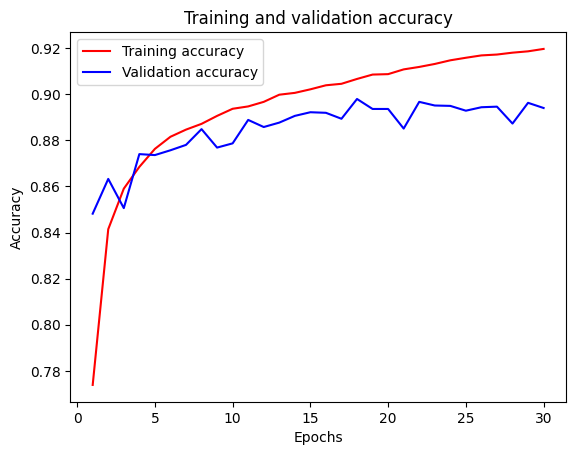

In [24]:
# show what the predictions look like for a multi-class classification problem
# pretty!

# learning curve
import matplotlib.pyplot as plt

# accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# loss
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "r" is for "solid red line"
plt.plot(epochs, acc, 'r', label='Training accuracy')
# b is for "solid blue line"
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [25]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# see how the model did!
preds = network.predict(test_images)
preds # if you look at preds, there's actually a probability in there...

# here it is! almost a perfect prediction
# actual is left, predicted is top
# names can be found by inspecting Y
matrix = confusion_matrix(test_labels.argmax(axis=1), preds.argmax(axis=1))
matrix

  1/313 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step

 34/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

 67/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 98/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

131/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

164/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

198/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

230/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

260/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

293/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[809,   1,  22,  58,   3,   0, 101,   0,   6,   0],
       [  1, 973,   1,  20,   2,   0,   2,   0,   1,   0],
       [ 18,   2, 830,  18,  73,   0,  56,   0,   3,   0],
       [  3,   4,  10, 948,  11,   0,  19,   0,   5,   0],
       [  0,   0, 106,  54, 774,   0,  65,   0,   1,   0],
       [  0,   0,   0,   0,   0, 969,   0,  18,   2,  11],
       [ 88,   1,  90,  51,  52,   0, 705,   0,  13,   0],
       [  0,   0,   0,   0,   0,  11,   0, 967,   0,  22],
       [  4,   0,   3,   4,   3,   4,   4,   7, 971,   0],
       [  0,   0,   0,   0,   0,   6,   1,  29,   0, 964]])

In [26]:
print(classification_report(test_labels.argmax(axis=1), preds.argmax(axis=1)))

              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1000
           1       0.99      0.97      0.98      1000
           2       0.78      0.83      0.81      1000
           3       0.82      0.95      0.88      1000
           4       0.84      0.77      0.81      1000
           5       0.98      0.97      0.97      1000
           6       0.74      0.70      0.72      1000
           7       0.95      0.97      0.96      1000
           8       0.97      0.97      0.97      1000
           9       0.97      0.96      0.97      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



# Try a Baseline Model for Fun
Just to show the power on DNNs, why not try a more familiar model like logistic regression? Because it's less accurate and actually takes MORE time!

In [27]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression(max_iter=100000000)

# warning: takes a long time to fit!

# had to make a copy of the labels because it expects a 1D array,
# not like the previous to_categorical() we used.
clf = LR.fit(train_images, # X
             copy_train_labels) # y (stored in original 5, 6, 7, 9 format... original labels)

In [28]:
# evaluate confusion matrix
preds = clf.predict(test_images)

confusion_matrix(copy_test_labels, preds)

array([[806,   2,  11,  53,   4,   3, 110,   0,  11,   0],
       [  4, 956,   4,  27,   4,   0,   3,   0,   2,   0],
       [ 26,   3, 739,  10, 124,   0,  85,   1,  12,   0],
       [ 26,  17,  17, 860,  30,   0,  39,   0,  11,   0],
       [  0,   2, 113,  36, 763,   0,  80,   0,   6,   0],
       [  0,   0,   0,   1,   0, 921,   0,  50,   6,  22],
       [144,   1, 123,  40, 101,   0, 567,   0,  24,   0],
       [  0,   0,   0,   0,   0,  33,   0, 940,   0,  27],
       [  7,   1,   8,  13,   4,   5,  21,   5, 936,   0],
       [  0,   1,   0,   0,   0,  13,   1,  35,   0, 950]])

In [29]:
# evaluate train results - it does OK,
# but NN does better!

print(classification_report(copy_test_labels, preds))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80      1000
           1       0.97      0.96      0.96      1000
           2       0.73      0.74      0.73      1000
           3       0.83      0.86      0.84      1000
           4       0.74      0.76      0.75      1000
           5       0.94      0.92      0.93      1000
           6       0.63      0.57      0.59      1000
           7       0.91      0.94      0.93      1000
           8       0.93      0.94      0.93      1000
           9       0.95      0.95      0.95      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



In [30]:
# interpret the output!
# what is going on with the number five?
# X is predicted, Y is actual